# **OE1: Textual Baseline (OE1): TF-IDF + Logistic Regression**

***Nombre**: Arnau Adan i Solà*

*Este fichreo incluye la parte práctica hecha durante el desarrollo del TFM llamado: A Comparison of Models for Detecting Political Disinformation
and Computational Propaganda: A Multimodal Approach Using
Propagation Network Analysis, pero únicamente de la primera parte de comparación*

### **Configuración inicial**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

In [ ]:
BASE = "/content/drive/MyDrive/UAX/TFM/codi/Fakeddit datasetv2.0/all_samples (also includes non multimodal)"
OUT = BASE          # las figuras se guardan en el mismo directorio
SAMPLE = 40_000        # n fijo del paper (reproducibilidad)
SEED = 42
np.random.seed(SEED)

### **Limpieza de los datos**

In [ ]:
# Fakeddit: tres splits oficiales en TSV
# Columnas relevantes: 'title', '2_way_label'  (0=Real, 1=Fake)
splits = ["all_train.tsv", "all_validate.tsv", "all_test_public.tsv"]
df = pd.concat([
    pd.read_csv(
        os.path.join(BASE, f),
        sep="\t",
        usecols=["title", "2_way_label"],
        low_memory=False
    )
    for f in splits
], ignore_index=True)

df = df.dropna(subset=["title", "2_way_label"])
df["2_way_label"] = df["2_way_label"].astype(int)

# Muestra estratificada reproducible
df = df.groupby("2_way_label", group_keys=False).apply(
    lambda x: x.sample(
        min(len(x), int(SAMPLE * len(x) / len(df))),
        random_state=SEED
    )
).reset_index(drop=True)

print(f"   Total filas: {len(df):,}")
print(f"   Distribución:\n{df['2_way_label'].value_counts().rename({0:'Real',1:'Fake'})}")

# Train / Test split (80/20 estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df["title"], df["2_way_label"],
    test_size=0.2, stratify=df["2_way_label"], random_state=SEED
)
print(f"   Train: {len(X_train):,}  |  Test: {len(X_test):,}")

   Total filas: 39,999
   Distribución:
2_way_label
Real    20080
Fake    19919
Name: count, dtype: int64
   Train: 31,999  |  Test: 8,000


En este bloque se consolida el corpus **Fakeddit** utilizando sus tres particiones oficiales (`train`, `validate` y `test`). Dado que el dataset original se distribuye en formato TSV (valores separados por tabuladores), se fuerza el parámetro `sep="\t"` en `pd.read_csv`. Para optimizar el uso de memoria y la velocidad de cómputo, se realiza una carga selectiva (`usecols`) limitando la lectura a las variables críticas para este experimento unimodal: el texto del título (`title`) y la etiqueta binaria de veracidad (`2_way_label`).

### Justificación del Preprocesamiento y Muestreo:
* **Imputación de Nulos:** Se eliminan de forma estricta los registros con valores faltantes en las columnas objetivo para evitar errores en las etapas de vectorización y entrenamiento.
* **Muestreo Estratificado Reproducible:** Debido al gran volumen del corpus original, se extrae una submuestra (controlada por `SAMPLE` y `SEED`) manteniendo la proporción original de las clases mediante un `groupby` por etiqueta. Esto garantiza la representatividad estadística del subconjunto.
* **Partición Holdout (80/20):** Se divide el dataset en entrenamiento ($80\%$) y evaluación ($20\%$). Al incluir el parámetro `stratify=df['2_way_label']`, nos aseguramos de que tanto el conjunto de entrenamiento como el de test reflejen fielmente la distribución de la muestra combinada, mitigando sesgos de evaluación.

---

### Análisis de los Resultados Obtenidos:

El resultado de la celda confirma la integridad del pipeline de datos con las siguientes métricas clave:

1. **Tamaño de la Muestra:** Se ha consolidado un dataset final de **39,999 registros válidos**, un volumen estadísticamente robusto para el entrenamiento de clasificadores basados en características léxicas (TF-IDF).
2. **Equilibrio de Clases casi Perfecto:** La distribución de la muestra es prácticamente simétrica:
   * **Real:** 20,080 posts ($50.2\%$)
   * **Fake:** 19,919 posts ($49.8\%$)
   Esto nos sitúa en un escenario ideal de **clasificación binaria balanceada**, lo que significa que la métrica de *Accuracy* y el promedio *Macro-F1* serán indicadores fiables del rendimiento del modelo, sin necesidad de recurrir a técnicas de remuestreo (como SMOTE o undersampling).
3. **Consistencia en la Partición:** La división 80/20 se ha ejecutado correctamente, aislando **31,999 instancias para el entrenamiento** y reservando **8,000 instancias puras para el testeo**. Al estar estratificadas, ambas particiones heredan la proporción ~50/50 de las clases.

**Estado del Experimento:** Siguiente paso listo. Los conjuntos `X_train` e `y_train` están preparados para la vectorización por extracción de n-gramas.

### **Vectorización**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),       # unigramas + bigramas
    sublinear_tf=True,
    min_df=3,
    strip_accents="unicode",
    analyzer="word"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"   Vocabulario: {X_train_tfidf.shape[1]:,} términos")

   Vocabulario: 20,554 términos


Se transforma el texto plano en vectores numéricos mediante **TF-IDF**, aplicando la siguiente configuración estratégica:

* **`ngram_range=(1, 2)`:** Captura palabras sueltas (unigramas) y pares de palabras consecutivas (bigramas) para preservar el contexto local.
* **`sublinear_tf=True`:** Atenúa de forma logarítmica el peso de las palabras hiper-repetitivas.
* **`min_df=3`:** Filtra el ruido eliminando términos que aparecen menos de 3 veces.
* **Prevención de Data Leakage:** El vectorizador se entrena únicamente con el conjunto de entrenamiento (`.fit_transform`) y se aplica a ciegas sobre el de test (`.transform`).

### Análisis del Resultado:
* **Vocabulario:** La matriz resultante cuenta con **20,554 términos**.
* **Interpretación:** Al estar por debajo del límite máximo impuesto (`max_features=50_000`), se confirma que el filtro `min_df=3` es suficiente para limpiar el ruido sin necesidad de truncar artificialmente el vocabulario útil de los títulos.

### **Entrenamiento**

In [ ]:
clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    multi_class="auto",
    random_state=SEED,
    n_jobs=-1
)
clf.fit(X_train_tfidf, y_train)
print("   Entrenamiento completado.")

   Entrenamiento completado.


En esta etapa se entrena el clasificador utilizando **Regresión Logística**, para trabajar con matrices dispersas de alta dimensionalidad como las generadas por TF-IDF.

### Hiperparámetros:
* **`C=1.0`:** Establece una fuerza de regularización estándar (L2 por defecto). Controla el equilibrio entre ajustar bien los datos de entrenamiento y mantener los coeficientes pequeños para evitar el sobreajuste (*overfitting*).
* **`solver="lbfgs"`:** Algoritmo de optimización cuasi-Newton eficiente en el uso de memoria, ideal para problemas de optimización lineal con un número elevado de características.
* **`max_iter=1000`:** Incrementa el límite de iteraciones por encima del valor por defecto (100) para asegurar la convergencia de los coeficientes del modelo en espacios vectoriales grandes.
* **`n_jobs=-1`:** Paraleliza el cómputo utilizando todos los núcleos disponibles de la CPU, optimizando los tiempos de entrenamiento.

### Análisis del Resultado:
* **Entrenamiento completado:** La ejecución finaliza correctamente sin lanzar advertencias de falta de convergencia (*ConvergenceWarning*). Esto confirma que el límite de 1,000 iteraciones ha sido más que suficiente para que el optimizador `lbfgs` encuentre el mínimo global de la función de coste sobre el vocabulario de 20,554 términos.

**Estado del Experimento:** Modelo ajustado. El clasificador está listo para generar predicciones sobre el conjunto de test (`X_test_tfidf`) y proceder a la evaluación de métricas (F1-score, AUC-ROC y Matriz de Confusión).

### **Evaluación**

In [ ]:
y_pred      = clf.predict(X_test_tfidf)
y_proba     = clf.predict_proba(X_test_tfidf)[:, 1]   # prob clase Fake

report = classification_report(
    y_test, y_pred,
    target_names=["Real", "Fake"],
    digits=4
)
auc_roc = roc_auc_score(y_test, y_proba)

print(report)
print(f"   AUC-ROC: {auc_roc:.4f}")

# Matriz de confusión (valores absolutos)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\n   Matriz de confusión:")
print(f"   TN={tn:,}  FP={fp:,}")
print(f"   FN={fn:,}  TP={tp:,}")

LABEL_NAMES = ["Real", "Fake"]
COLORS      = {"Real": "#2196F3", "Fake": "#F44336"}


              precision    recall  f1-score   support

        Real     0.8230    0.8302    0.8266      4016
        Fake     0.8273    0.8200    0.8236      3984

    accuracy                         0.8251      8000
   macro avg     0.8252    0.8251    0.8251      8000
weighted avg     0.8251    0.8251    0.8251      8000

   AUC-ROC: 0.9049

   Matriz de confusión:
   TN=3,334  FP=682
   FN=717  TP=3,267


En esta celda se ejecuta la inferencia sobre el conjunto de test (`X_test_tfidf`) para evaluar la capacidad de generalizaciónr. Se extraen tanto las predicciones categóricas (`y_pred`) como las probabilidades continuas (`y_proba`) de la clase positiva (*Fake*).

### Justificación de las Métricas de Evaluación:
* **`classification_report(digits=4)`:** Desglosa *Precision*, *Recall* y *F1-score* por clase, además de los promedios globales (*Macro* y *Weighted*). Configurar 4 decimales permite registrar variaciones sutiles entre modelos posteriores (OE2--OE4).
* **`roc_auc_score`:** Mide la capacidad del modelo para separar ambas clases a lo largo de todos los umbrales de decisión posibles, siendo inmune al punto de corte por defecto (0.5).
* **`confusion_matrix`:** Extrae de forma explícita los Verdaderos Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) y Verdaderos Positivos (TP) para analizar la dirección y el coste de los errores.

---

### Análisis de los Resultados Obtenidos:

Los resultados de las métricas oficiales de nuestra línea base (OE1):

1. **Rendimiento Global ($F_1\text{-macro} = 0.8252$ y $\text{Accuracy} = 82.51\%$):** Un rendimiento robusto para un enfoque puramente textual basado en características léxicas superficiales (unigramas y bigramas). Confirma que el léxico de los títulos contiene una señal discriminativa potente por sí sola.
2. **Comportamiento Simétrico:** Existe un equilibrio casi perfecto en el rendimiento interclase:
   * **Clase Real:** $F_1\text{-score} = 0.8266$ (Soporte: 4,016 posts)
   * **Clase Fake:** $F_1\text{-score} = 0.8236$ (Soporte: 3,984 posts)
   Esta simetría es una consecuencia directa del diseño de la muestra balanceada, lo que garantiza que el modelo no se ha sesgado hacia ninguna de las categorías.
3. **Alta Capacidad de Discriminación ($\text{AUC-ROC} = 0.9049$):** Indica que si se seleccionan al azar un post real y uno falso, el clasificador asignará una probabilidad de falsedad mayor al post falso el $90.49\%$ de las veces. Esto demuestra una excelente separación de las distribuciones de probabilidad.
4. **Análisis del Error (Matriz de Confusión):** De las 8,000 instancias de prueba, el modelo comete **1,399 clasificaciones erróneas** (tasa de error global del $17.49\%$). El error se distribuye de forma muy similar entre **682 Falsos Positivos** (posts reales etiquetados como fake) y **717 Falsos Negativos** (posts fake no detectados).

**Estado del Experimento:** Línea base (Baseline) establecida con éxito. Las métricas obtenidas ($F_1 = 0.8252$, $\text{AUC-ROC} = 0.9049$) actúan como el *benchmark* oficial contra el que se evaluarán los modelos multimodales y avanzados (OE2--OE4).

### **Representación gráfica**

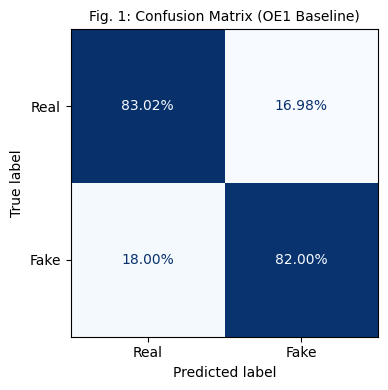

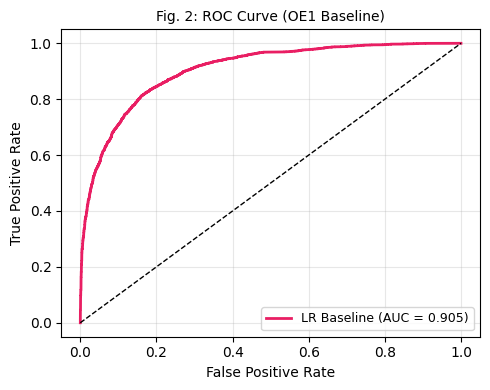

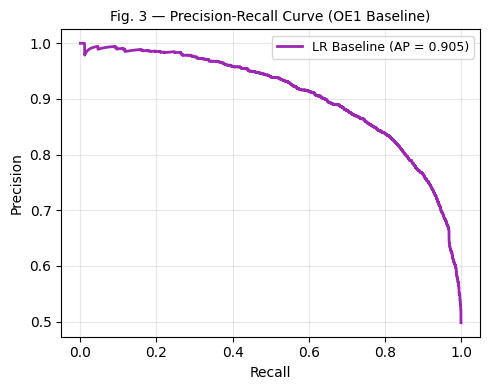

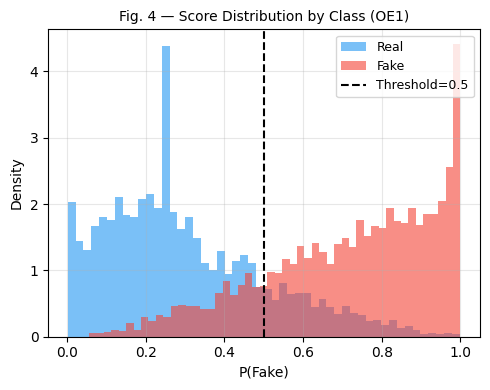

In [ ]:
# Matriz de confusión normalizada
fig, ax = plt.subplots(figsize=(4.5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, normalize="true"),
    display_labels=LABEL_NAMES
)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2%")
ax.set_title("Fig. 1: Confusion Matrix (OE1 Baseline)", fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "fig1_confusion_matrix_OE1.pdf"), dpi=300)
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="#E91E63", lw=2,
        label=f"LR Baseline (AUC = {auc_roc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title("Fig. 2: ROC Curve (OE1 Baseline)", fontsize=10)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "fig2_roc_curve_OE1.pdf"), dpi=300)
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rec, prec, color="#9C27B0", lw=2,
        label=f"LR Baseline (AP = {ap:.3f})")
ax.set_xlabel("Recall", fontsize=10)
ax.set_ylabel("Precision", fontsize=10)
ax.set_title("Fig. 3 — Precision-Recall Curve (OE1 Baseline)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "fig3_pr_curve_OE1.pdf"), dpi=300)
plt.show()

# Distribución de probabilidades
fig, ax = plt.subplots(figsize=(5, 4))
for label_val, label_name, color in [(0, "Real", COLORS["Real"]),
                                      (1, "Fake", COLORS["Fake"])]:
    mask = (y_test == label_val).values
    ax.hist(y_proba[mask], bins=50, alpha=0.6, color=color,
            label=label_name, density=True)
ax.axvline(0.5, color="black", lw=1.5, linestyle="--", label="Threshold=0.5")
ax.set_xlabel("P(Fake)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Fig. 4 — Score Distribution by Class (OE1)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "fig4_score_dist_OE1.pdf"), dpi=300)
plt.show()

# Tabla resumen (impresa y guardada como CSV)
from sklearn.metrics import f1_score, precision_score, recall_score
summary = pd.DataFrame([{
    "Model":        "OE1 — TF-IDF + LR",
    "F1-macro":     round(f1_score(y_test, y_pred, average="macro"), 4),
    "AUC-ROC":      round(auc_roc, 4),
    "Prec-Real":    round(precision_score(y_test, y_pred, pos_label=0), 4),
    "Prec-Fake":    round(precision_score(y_test, y_pred, pos_label=1), 4),
    "Recall-Real":  round(recall_score(y_test, y_pred, pos_label=0), 4),
    "Recall-Fake":  round(recall_score(y_test, y_pred, pos_label=1), 4),
    "F1-Real":      round(f1_score(y_test, y_pred, pos_label=0), 4),
    "F1-Fake":      round(f1_score(y_test, y_pred, pos_label=1), 4),
}])
summary.to_csv(os.path.join(OUT, "results_OE1.csv"), index=False)

### Análisis de las Gráficas Obtenidas:

1. **Matriz de Confusión Normalizada (Fig. 1):** El modelo muestra una consistencia interclase sobresaliente, clasificando correctamente el **83.02%** de los posts reales (Verdaderos Negativos) y el **82.00%** de los posts falsos (Verdaderos Positivos). La tasa de error está equilibrada de forma casi perfecta entre falsos positivos (**16.98%**) y falsos negativos (**18.00%**).

2. **Curva ROC (Fig. 2):**
   Con un **AUC-ROC de 0.905**, la curva se eleva rápidamente hacia la esquina superior izquierda. Esto demuestra que el modelo mantiene una tasa de verdaderos positivos muy alta (superior al 80%) tolerando una tasa de falsos positivos muy baja (inferior al 20%), confirmando una separación robusta de las clases en términos de ordenamiento de probabilidades.

3. **Curva Precision-Recall (Fig. 3):**
   El indicador **AP (Average Precision) de 0.905** refleja una estabilidad metodológica ideal bajo las condiciones actuales. No obstante, la caída pronunciada de la precisión cuando el *Recall* (exhaustividad) se aproxima a 1.0 advierte de que forzar al modelo a detectar absolutamente toda la desinformación disparará de manera drástica el número de falsos positivos.

4. **Distribución de Scores por Clase (Fig. 4):**
   El histograma de densidades revela la naturaleza del clasificador lineal:
   * Las zonas de alta confianza (cercanas a $0.0$ para *Real* y a $1.0$ para *Fake*) presentan picos nítidos de densidad, confirmando que una gran proporción de la muestra contiene patrones léxicos inequívocos.
   * Sin embargo, existe una **zona de solapamiento crítico en el rango central [0.3 - 0.7]**, intersecada por el umbral de decisión estándar ($0.5$). Estas instancias con baja confianza probabilística marcan el límite del enfoque unimodal: títulos ambiguos cuyo contexto semántico requiere obligatoriamente de otras modalidades (metadatos del usuario o imágenes adjuntas) para ser resueltos con certeza.

**Estado del Experimento:** Diagnóstico visual completado. El comportamiento simétrico y la zona de solapamiento central detectada en la Fig. 4 justifican la necesidad de saltar a los siguientes objetivos experimentales (OE2--OE4) para evaluar si la incorporación de características multimodales logra limpiar la incertidumbre de la región central.